# Priors

Testing the impact of enforcing priors on model predictions, for both label bounds and a sum prior.

In [37]:
# imports 
import matplotlib.pyplot as plt
plt.style.use('thesis')
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import median_abs_deviation as mad

## Label Bounds

In [38]:
# comparing no bounds, log, enforced bounds
base = '/avatar/vmehta/sfh_1000_3bins_20260402_162314/bounds-testing'
basic_pred = np.load(f'{base}/basic-model/snr1000_pred.npy')
basic_true = np.load(f'{base}/basic-model/snr1000_true.npy')
log_pred = np.load(f'{base}/log-model/snr1000_pred.npy')
log_true = np.load(f'{base}/log-model/snr1000_true.npy')
bounds_pred = np.load(f'{base}/bounds-model/snr1000_pred.npy')
bounds_true = np.load(f'{base}/bounds-model/snr1000_true.npy')
res_bounds = bounds_true - bounds_pred
res_log = log_true - log_pred

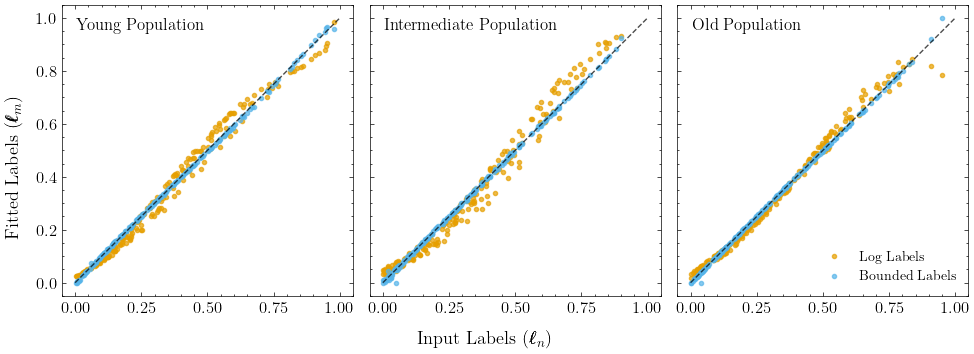

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3.7), sharex=True, sharey=True)

for i in range(3):
    ax[i].plot(log_true[:, i], log_pred[:, i], '.', alpha=0.7, label='Log Labels')
    ax[i].plot(bounds_true[:, i], bounds_pred[:, i], '.', alpha=0.7, label='Bounded Labels')
    ax[i].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[i].set_box_aspect(1)

ax[0].text(0.05, 0.95, 'Young Population', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.95, 'Intermediate Population', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[2].text(0.05, 0.95, 'Old Population', transform=ax[2].transAxes, fontsize=12, verticalalignment='top')
ax[2].legend(loc='lower right', fontsize=10)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$')
fig.supylabel(r'Fitted Labels $(\pmb\ell_m)$')
plt.tight_layout()
plt.savefig('/home/vmehta/honours-project/thesis/figures/logvslin.pdf', format='pdf')
plt.show()

In [39]:
print(f"MAD for log-models: {mad(res_log, axis=0)}")
print(f"Percentage of points outside 3MAD: {((np.abs(res_log) > 3*mad(res_log, axis=0)).sum(axis=0) / res_log.shape[0]) * 100}")
print(f"MAD for linear-models: {mad(res_bounds, axis=0)}")
print(f"Percentage of points outside 3MAD: {((np.abs(res_bounds) > 3*mad(res_bounds, axis=0)).sum(axis=0) / res_bounds.shape[0]) * 100}")

MAD for log-models: [0.02037815 0.02507436 0.01390223]
Percentage of points outside 3MAD: [0.5 7.5 6. ]
MAD for linear-models: [0.00295847 0.00225373 0.00149192]
Percentage of points outside 3MAD: [7. 6. 6.]


## Sum Prior

In [2]:
# loading data and defining functions
root = "sfh_100_20260129_104132"
real = np.vstack(10**(np.load(f"/avatar/vmehta/{root}/snr_all_true.npy")))

def load_data(sigma):
    if sigma == None:
        pred = np.vstack(10**(np.load(f"/avatar/vmehta/{root}/snr_all_pred.npy")))
    else:
        pred = np.vstack(10**(np.load(f"/avatar/vmehta/{root}/snr_all_pred_{sigma}.npy")))

    return pred

# Bin setup (used in multiple places)
bin_arr = np.r_[np.array([0.1, 20, 50, 100, 200, 500])*1e6, np.logspace(9.5, 10.15, 5)]
binning = np.log10(bin_arr)
bin_widths = np.diff(binning)
bin_centers = binning[:-1] + bin_widths/2

def rmse(pred):
    rmse = np.sqrt(mean_squared_error(real, pred, multioutput='raw_values'))
    overall_rmse = np.sqrt(mean_squared_error(real, pred))
    return rmse, overall_rmse

## Accuracy
How does enforcing priors impact the accuracy of predicted SFH?

In [3]:
rmse(load_data(None))[1]

np.float64(2123950058.252836)

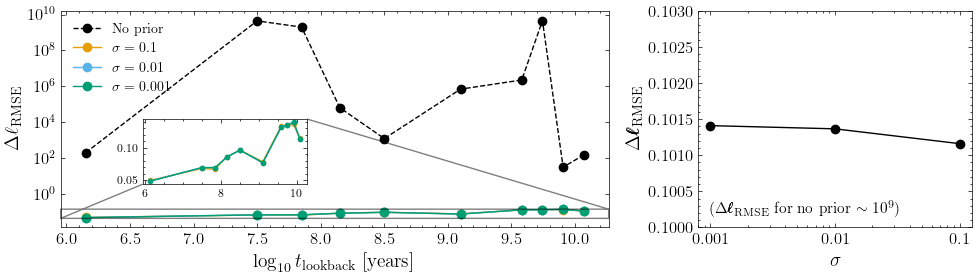

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,3), gridspec_kw={'width_ratios': [2, 1]})

ax[0].plot(bin_centers, rmse(load_data(None))[0], 'ko--')
for s in ["0_1", "0_0_1", "0_0_0_1"]:
    pred = load_data(s)
    ax[0].plot(bin_centers, rmse(pred)[0], marker='o')
ax[0].legend(['No prior', '$\\sigma=0.1$', '$\\sigma=0.01$', '$\\sigma=0.001$'], fontsize=10, loc='upper left')
ax[0].set_xlabel('$\\log_{10}t_\\mathrm{lookback}$ [years]')
ax[0].set_ylabel('$\\Delta\\ell_\\mathrm{RMSE}$')
ax[0].set_yscale('log')

inset = ax[0].inset_axes([0.15, 0.2, 0.3, 0.3])
inset.plot(bin_centers, rmse(load_data("0_1"))[0], marker='o', markersize=3)
inset.plot(bin_centers, rmse(load_data("0_0_1"))[0], marker='o', markersize=3)
inset.plot(bin_centers, rmse(load_data("0_0_0_1"))[0], marker='o', markersize=3)
inset.tick_params(axis='both', which='major', labelsize=8)

ax[0].indicate_inset_zoom(inset, edgecolor="black")

ax[1].plot([0.1, 0.01, 0.001], [rmse(load_data("0_1"))[1], rmse(load_data("0_0_1"))[1], rmse(load_data("0_0_0_1"))[1]], 'ko-')
ax[1].set_xscale('log')
ax[1].set_xlabel('$\\sigma$')
ax[1].set_ylabel('$\\Delta\\pmb\\ell_\\mathrm{RMSE}$')
ax[1].set_ylim(0.10,0.103)
ax[1].set_xticks([0.1, 0.01, 0.001])
ax[1].set_xticklabels(['0.1', '0.01', '0.001'])
ax[1].text(0.001, 0.1002, '($\\Delta\\pmb\\ell_\\mathrm{RMSE}$ for no prior $\\sim10^{9}$)')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/priors_rmse.pdf')
plt.show()

## Precision
How does enforcing priors impact the label sums? Plot histograms for the sum of all labels.

In [33]:
def plot_hist(data, ax=None, bins=50, focus_percentile=90.0, color='C0', alpha=0.7, density=False, plotmean=True, plotmed=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if data.size == 0:
        raise ValueError('data is empty after filtering non-finite values')

    lowp = (100 - focus_percentile) / 2.0
    highp = 100 - lowp
    vmin, vmax = np.percentile(data, [lowp, highp])

    clipped = data[(data >= vmin) & (data <= vmax)]
    ax.hist(clipped, bins=bins, color=color, alpha=alpha, density=density)
    if plotmean:
        ax.axvline(np.mean(data), color='k', linestyle=':', linewidth=1, label='Mean')
    if plotmed:
        ax.axvline(np.median(data), color='k', linestyle='--', linewidth=1, label='Median')

    return ax

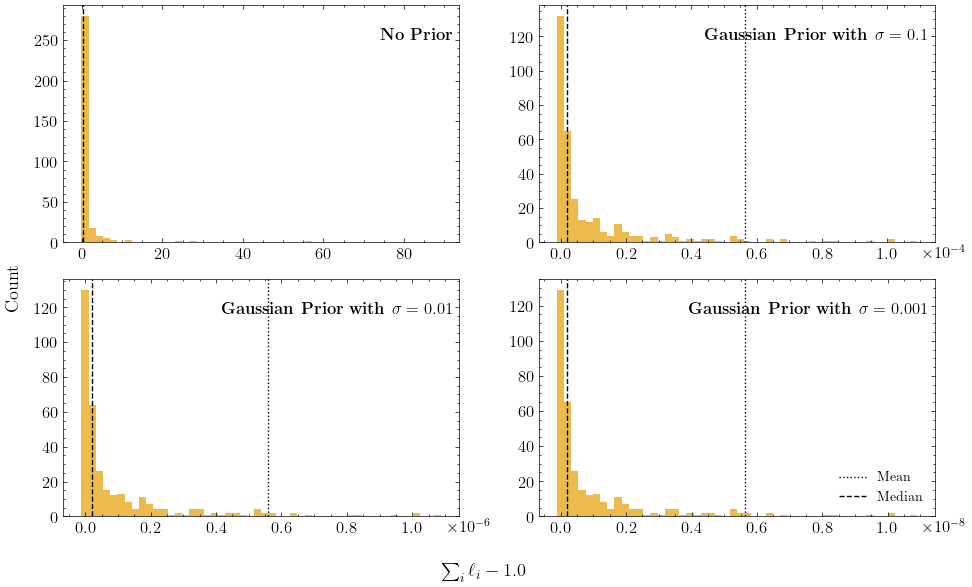

In [40]:
# having a look at some of the distributions
label_sum_none = np.sum(load_data(sigma=None), axis=1)
label_sum_0_1 = np.sum(load_data(sigma="0_1"), axis=1)
label_sum_0_0_1 = np.sum(load_data(sigma="0_0_1"), axis=1)
label_sum_0_0_0_1 = np.sum(load_data(sigma="0_0_0_1"), axis=1)

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
plot_hist(label_sum_none-1, focus_percentile=84, ax=ax[0, 0], plotmean=False)
plot_hist(label_sum_0_1-1, focus_percentile=84, ax=ax[0, 1])
plot_hist(label_sum_0_0_1-1, focus_percentile=84, ax=ax[1, 0])
plot_hist(label_sum_0_0_0_1-1, focus_percentile=84, ax=ax[1, 1])
fig.supxlabel('$\\sum_i\\ell_i-1.0$')
fig.supylabel('Count')
ax[1,1].legend(loc='lower right', fontsize=10)
ax[0,0].text(0.8, 0.9, '\\textbf{No Prior}', transform=ax[0,0].transAxes, fontsize=12, verticalalignment='top')
ax[0,1].text(0.42, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.1$}', transform=ax[0,1].transAxes, fontsize=12, verticalalignment='top')
ax[1,0].text(0.4, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.01$}', transform=ax[1,0].transAxes, fontsize=12, verticalalignment='top')
ax[1,1].text(0.38, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.001$}', transform=ax[1,1].transAxes, fontsize=12, verticalalignment='top')
ax[0,1].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax[0,1].xaxis.get_offset_text().set_visible(False)
ax[0,1].text(0.97, -0.01, '$\\times10^{-4}$', transform=ax[0,1].transAxes, fontsize=12, verticalalignment='top')
ax[1,0].xaxis.get_offset_text().set_visible(False)
ax[1,0].text(0.97, -0.01, '$\\times10^{-6}$', transform=ax[1,0].transAxes, fontsize=12, verticalalignment='top')
ax[1,1].xaxis.get_offset_text().set_visible(False)
ax[1,1].text(0.97, -0.01, '$\\times10^{-8}$', transform=ax[1,1].transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/prior_histograms.pdf', format='pdf')

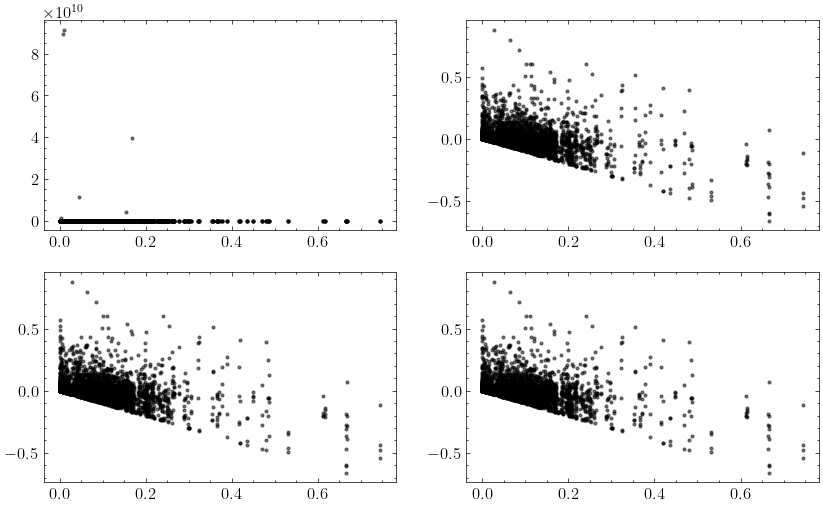

In [28]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0,0].plot(real, load_data(None)-real, 'ko', markersize=2, alpha=0.5)
ax[0,1].plot(real, load_data("0_1")-real, 'ko', markersize=2, alpha=0.5)
ax[1,0].plot(real, load_data("0_0_1")-real, 'ko', markersize=2, alpha=0.5)
ax[1,1].plot(real, load_data("0_0_0_1")-real, 'ko', markersize=2, alpha=0.5)
plt.show()